# Libraries & Datasets

Lets start with importing the necessary libraries.

In [1]:
import matplotlib.pyplot as plt
from pathlib import Path
import pandas as pd
import numpy as np
import string
import os

## Lets load our datasets

We need to remember that we will be working with the ASL dataset in `csv` format.

In [2]:
# We'll assume that the csv datasets are in the same folder than this notebook, and are
# named as follows:
# Train dataset: sign_mnist_train.csv
# Test or validation dataset: sign_mnist_valid.csv

data_path =  Path.cwd()
train_df = pd.read_csv(os.path.join(data_path, 'sign_mnist_train.csv'))
val_df  = pd.read_csv(os.path.join(data_path, 'sign_mnist_valid.csv'))


In [3]:
# Now, lets check what we got in our dataset...
train_df.head(5)

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,3,107,118,127,134,139,143,146,150,153,...,207,207,207,207,206,206,206,204,203,202
1,6,155,157,156,156,156,157,156,158,158,...,69,149,128,87,94,163,175,103,135,149
2,2,187,188,188,187,187,186,187,188,187,...,202,201,200,199,198,199,198,195,194,195
3,2,211,211,212,212,211,210,211,210,210,...,235,234,233,231,230,226,225,222,229,163
4,12,164,167,170,172,176,179,180,184,185,...,92,105,105,108,133,163,157,163,164,179


... and after taking a quick peek, we can see that we already that we have our target column as `label` and a description of the grayscale intensity for each pixel of each image.

Then, we need to load our train dataset

In [4]:
# First, we load each array from the test and train sets
y_train = np.array(train_df['label'])
y_val   = np.array(val_df['label'])

# Then, we delete the `label` column from our datasets...
del train_df['label']
del val_df['label']

# ... so we can load only the pixel arrays easily into other variables
x_train = train_df.values.astype(np.float32)
x_val  = val_df.values.astype(np.float32)

# But, what about data leakage?

Because we're looking to minimize the phenomenom of data leakage, we should always look out for the way that we split our train dataset to validate the accuracy of our models... so, we now need to create our own split function to have the standard splitting practice:

- Train dataset
- Validation dataset
- Test dataset

In [5]:
def split_val_into_test(
        x: np.array,
        y:np.array,
        pct: float = 0.5,
        shuffle: bool =True):

    """  
    Parameters:

        - x: variables or inputs of the validation dataset (NumPy array).
        - y: Labels of the validation dataset (NumPy array).
        - pct: Proportion of the validation set to allocate to the test set (default is 0.5).
        - shuffle: Whether to shuffle the data before splitting (default is True).



    Returns:

        - x_val: Features for the validation set.
        - y_val: Labels for the validation set.
        - x_test: Features for the test set.
        - y_test: Labels for the test set. 
    """

    if shuffle:
        # Lets create some random indices to shuffle our dataset
        indices = np.arange(len(x))
        np.random.shuffle(indices)
        x = x[indices]
        y = y[indices]

    # Lets store for a little while the splitter percentage
    num_test_samples = int(len(x) * pct)

    # Now, we create our validation and test datasets
    x_test = x[:num_test_samples]
    y_test = y[:num_test_samples]

    x_val  = x[num_test_samples:]
    y_val  = y[num_test_samples:]

    return x_val, y_val, x_test, y_test

Now, lets split our validation dataset into a `val` and `test` sets using the default values for the `pct` and `shuffle` parameters

In [6]:
x_val, y_val, x_test, y_test = split_val_into_test(x_val, y_val)

# Getting used to the target variable

The target variable `y_train`, `y_val` and `y_test` has a numeric value. Each number or integer represented in these columns corresponds directly to the letters of the alphabet in order. 

So, we can create an array or list that could house this logic

In [7]:
alphabet = list(string.ascii_lowercase) # we create a list containing the letters of the alphabet

#But, we should remember that the letter J and the letter Z can not be taken into account...
alphabet.remove('j')
alphabet.remove('z')

#Finally, we check that all the letters that we need are correctly created
alphabet

['a',
 'b',
 'c',
 'd',
 'e',
 'f',
 'g',
 'h',
 'i',
 'k',
 'l',
 'm',
 'n',
 'o',
 'p',
 'q',
 'r',
 's',
 't',
 'u',
 'v',
 'w',
 'x',
 'y']

# Now, what should we do?

We need to remember that our dataset is using a grayscale, and these types of numbers could be problematic for a Neural Network.

So, we can make a decision here: wheter we normalise the data, or we can try to use it as it is.

With that in mind, I choose to normalise it because our model should learn from patterns, then, a normalized image or description of an image could contain these patterns and make them more "visible" for the model.

In [8]:
# We'll be using the basic normalisation: Z-score
def normalise_ASL( x_mean: float, x_std: float, x_data: pd.DataFrame):
    return (x_data - x_mean) / x_std

In [9]:
# Now, we apply this normalisation to our train DataFrame
x_mean = x_train.mean()
x_std  = x_train.std()

# We will be overwriting each DataFrame
x_train = normalise_ASL(x_mean, x_std, x_train)
x_val   = normalise_ASL(x_mean, x_std, x_val)
x_test = normalise_ASL(x_mean, x_std, x_test)

# Lets see a little bit of our training dataset in greyscale

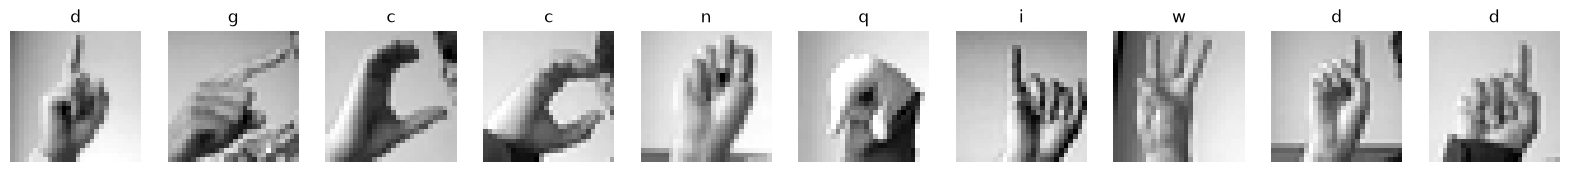

In [10]:
def plot_sign(image):
    plt.figure(figsize=(5,5))
    plt.imshow(image.reshape(28,28), cmap=plt.get_cmap('gray'))
    plt.axis('off')
    plt.show()

fig, ax = plt.subplots(1, 10, figsize=(20, 2))
for i in range(10):
    ax[i].imshow(x_train[i].reshape(28, 28), cmap='gray')
    ax[i].axis('off')
    ax[i].set_title(alphabet[y_train[i]])
plt.show()

# Now, we will be creating our classificator using Neural Networks

First, we need to create mini-batches for our training loop, because we are not using a PC built by NASA.

In [11]:
def create_minibatches(mb_size, x, y, shuffle = True):

    '''
    mb_size: The size of each mini-batch.
    x: The feature data (input).
    y: The label data (output).
    shuffle: A boolean indicating whether to shuffle the data before creating batches (default is True).
    '''

    assert x.shape[0] == y.shape[0]
    total_data = x.shape[0]
    if shuffle:
        idxs = np.arange(total_data)
        np.random.shuffle(idxs)
        x = x[idxs]
        y = y[idxs]
        
    return ((x[i:i+mb_size], y[i:i+mb_size]) for i in range(0, total_data, mb_size))

# Now, we'll be creating our proper Neural Network class

## Linear Class

We need to define a class to declara a fully connected layer in our neural network. This will help us to initializa the Weight matrices, the bias vector and the forward and backward passes.

In [12]:
# We need so we can append new attributes to our objects
class np_tensor(np.ndarray): pass


class Linear():

    def __init__(self, input_size, output_size):
        '''
        Constructor

        Used to create the Weight matrix and bias vector using np_tensors
        '''
        self.W = (np.random.randn(output_size, input_size) / np.sqrt(input_size/2)).view(np_tensor)
        self.b = (np.zeros((output_size, 1))).view(np_tensor)


    def __call__(self, X):
        '''
        This is the forward pass of a Neural Network.

        This is what computes the result of using the weight matrices and the bias vector
        '''
        Z = self.W @ X + self.b
        return Z
    
    def backward(self, X, Z):
        '''
        This is the backward pass, which recalculates the weights of our matrices after using a loss function.
        '''
        X.grad = self.W.T @ Z.grad
        self.W.grad = Z.grad @ X.T
        self.b.grad = np.sum(Z.grad, axis = 1, keepdims=True)

## Activation class: ReLU

We will keep it simple and use ReLU as our activation class.

In [13]:
class ReLU():
    
    def __call__(self, Z):
        return np.maximum(0, Z)
    
    def backward(self, Z, A):
        Z.grad = A.grad.copy()
        Z.grad[Z <= 0] = 0

## Sequential Class

In [14]:
class Sequential_layers():

    def __init__(self, layers):
        self.layers = layers
        self.x = None
        self.outputs = {}


    def __call__(self, X):
        self.x = X
        self.outputs['l0'] = self.x
        for i, layer in enumerate(self.layers, 1):
            self.x = layer(self.x)
            self.outputs['l'+str(i)]=self.x
        return self.x
    

    def backward(self):
        for i in reversed(range(len(self.layers))):
            self.layers[i].backward(self.outputs['l'+str(i)], self.outputs['l'+str(i+1)])


    def update(self, learning_rate = 1e-3):
        for layer in self.layers:
            if isinstance(layer, ReLU): continue
            layer.W = layer.W - learning_rate * layer.W.grad
            layer.b = layer.b - learning_rate * layer.b.grad

            
    def predict(self, X):
        return np.argmax(self.__call__(X))

## Cost Function

In [15]:
def softmaxXEntropy(x, y):

    batch_size = x.shape[1]
    exp_scores = np.exp(x)
    probs = exp_scores / exp_scores.sum(axis = 0)
    preds = probs.copy()

    # Calculate the cost
    y_hat = probs[y.squeeze(), np.arange(batch_size)]
    cost = np.sum(-np.log(y_hat)) / batch_size
    
    # Calculate gradient
    probs[y.squeeze(), np.arange(batch_size)] -= 1 #dl/dx
    x.grad = probs.copy()

    return preds, cost

## Training loop

In [16]:
def accuracy(x, y, mb_size):
    correct = 0
    total = 0
    for i, (x, y) in enumerate(create_minibatches(mb_size, x, y)):
        pred = model(x.T.view(np_tensor))
        correct += np.sum(np.argmax(pred, axis=0) == y.squeeze())
        total += pred.shape[1]
    return correct/total

def train(model, epochs, mb_size=128, learning_rate = 1e-3):
    for epoch in range(epochs):
        for i, (x, y) in enumerate(create_minibatches(mb_size, x_train, y_train)):
            
            scores = model(x.T.view(np_tensor))
            _, cost = softmaxXEntropy(scores, y)
            
            model.backward()
            
            model.update(learning_rate)
        
        print(f'cost: {cost}, accuracy: {accuracy(x_val, y_val, mb_size)}')

# Now, we create our model and it's hyperparameters

In [17]:
model = Sequential_layers([Linear(784, 200), ReLU(), Linear(200, 200), ReLU(), Linear(200, 24)])
mb_size = 128
learning_rate = 1e-3
epochs = 40



In [18]:
train(model, epochs, mb_size, learning_rate)

cost: 0.06386893751006802, accuracy: 0.7702175125488009
cost: 0.018109341066314327, accuracy: 0.7852760736196319
cost: 0.01088622168998937, accuracy: 0.7916899051868377
cost: 0.007721220808537612, accuracy: 0.795872838817624
cost: 0.004729329947799894, accuracy: 0.7955939765755716
cost: 0.003929034445674699, accuracy: 0.795872838817624
cost: 0.002512079692308335, accuracy: 0.7975460122699386
cost: 0.0017756702768167948, accuracy: 0.8006134969325154
cost: 0.0018449272543333611, accuracy: 0.7994980479643057
cost: 0.0012745811059357585, accuracy: 0.800334634690463
cost: 0.0017200376930344018, accuracy: 0.8008923591745678
cost: 0.001228074879014795, accuracy: 0.7992191857222533
cost: 0.0011232714943667363, accuracy: 0.7994980479643057
cost: 0.0006362810075124731, accuracy: 0.8008923591745678
cost: 0.001317535564510901, accuracy: 0.8011712214166202
cost: 0.0009989338554974912, accuracy: 0.8014500836586727
cost: 0.001064732491857962, accuracy: 0.8008923591745678
cost: 0.001214421064103514, a

# We finally test our model with random data from our test split

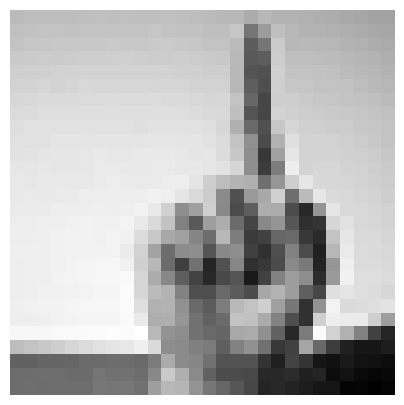

The predicted value is: d
The real value is:d


In [22]:
idx = np.random.randint(len(y_test))
plot_sign(x_test[idx].reshape(28,28))
pred = model.predict(x_test[idx].reshape(-1, 1))
print(f'The predicted value is: {alphabet[pred]}\nThe real value is:{alphabet[y_test[idx]]}')

# And using all the available test split...

